# PCW Lesson 7: Networks 1 - Feed-Forward Neural Networks

**Student**: Katia Gwaneza Nkurunziza  
**Date**: Session 7, Fall 2026  
**Topics**: Feed-forward neural networks, layers, units, activation functions, matrix representation of a forward pass, perceptrons

This session (and the next) introduces feed-forward neural networks: drawing basic architectures, writing them as nested functions, describing them with matrices, and running the forward pass. Backpropagation and learning are introduced as concepts here, covered in depth next session.

## Readings

1. **Murphy, K. (2022), Chapter 13: sections 13.0, 13.1, 13.2, 13.3.1, 13.3.2** - the basic matrix algebra of neural networks. Sections 13.0-13.2 set up the network structure; 13.3 introduces learning rules (covered more in later sessions).
2. **3Blue1Brown (2017). *But what is a neural network?*** - visual intro to neurons, layers, weights, and biases.
3. **3Blue1Brown (2017). *Gradient descent, how neural networks learn*** - intuition for the learning procedure (previewed here, covered in depth next session).

Key vocab: neural network, unit, connection, graph/nodes/edges, matrix, piecewise-linear function.

## Question 1 of 6: Basic Questions for Class

The code below (Code Cell 1) describes a neural network using `tensorflow.keras`. I interviewed an LLM about it, then verified every claim by actually running the code myself, since Session 3-6 taught me not to trust an LLM's read of code without checking.

**a. What data is it training on?**

MNIST: 60,000 training images and 10,000 validation images of handwritten digits (0-9), each a 28x28 grayscale image. Pixel values are normalized from the raw 0-255 range down to 0-1 (`x_train.astype('float32') / 255`).

**b. What is it learning to do?**

Multi-class classification: given an image, predict which digit (0-9) it shows. 10 possible output classes.

**c. How many layers does it have?**

3 trainable layers: two hidden `Dense` layers and one output `Dense` layer. The `Flatten` layer before them reshapes the 28x28 image into a flat 784-length vector but has no weights of its own, so it isn't usually counted as a "layer" in the learning sense.

**d. What is a layer?**

A group of units that all receive the exact same set of inputs, each computing its own weighted sum of those inputs (plus a bias) followed by an activation function. Layers stack: one layer's outputs become the next layer's inputs.

**e. How many units in the layers?**

128 units in the first hidden layer, 64 in the second hidden layer, 10 in the output layer (one output unit per digit class).

**f. What is a unit?**

A single computational node. It takes a weighted sum of every input it receives, adds one bias term, then passes that sum through an activation function to produce one output number.

**g. What are the units' activation functions?**

Both hidden layers use `sigmoid`. The output layer has **no activation specified**, which Keras defaults to linear (identity). I confirmed this is a real problem, not a stylistic choice, see the bug writeup below.

**h. How are the units connected to each other (i.e., how are the weights set initially)?**

Fully connected (`Dense`): every unit in one layer connects to every unit in the next layer. Weights are NOT initialized to zero, Keras uses Glorot/Xavier uniform initialization by default, small random values that break symmetry between units so they learn different features.

**i. What is a connection weight?**

A single number attached to one specific connection between two units. It scales how much that upstream unit's output contributes to the downstream unit's weighted sum. These are exactly what gets adjusted during training.

**j. What is the output?**

A vector of 10 numbers, one per digit class. With the intended (fixed) setup, these should be probabilities that sum to 1 (via softmax), and the model predicts whichever digit has the highest value.

**k. How well is it performing the classification?**

See the bug writeup below, the answer is "barely at all" with the code exactly as given, and "quite well" once two specific bugs are fixed.

## Code Cell 1 of 2: The Keras MNIST Network (as given in the PCW)

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.losses import BinaryCrossentropy

(x_train, y_train), (x_val, y_val) = mnist.load_data()

x_train = x_train.astype('float32') / 255
y_train = to_categorical(y_train)

model = tf.keras.Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='sigmoid'),
    Dense(64, activation='sigmoid'),
    Dense(10)
])

model.compile(optimizer='SGD',
              loss=BinaryCrossentropy(),
              metrics=['accuracy'])

model.summary()

/Users/katiankurunzizagwaneza/workspace/github.com/katian28/cs156-katia/.venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [2]:
# Running exactly as given: model.fit(x_train, y_train, epochs=10)
# Reduced to 3 epochs here to keep runtime short; the flat accuracy is already visible by epoch 1.
history_broken = model.fit(x_train, y_train, epochs=3, verbose=2)
print(f"\nFinal training accuracy (broken version): {history_broken.history['accuracy'][-1]:.4f}")

Epoch 1/3


1875/1875 - 2s - 940us/step - accuracy: 0.0896 - loss: 2.6963


Epoch 2/3


1875/1875 - 1s - 728us/step - accuracy: 0.0975 - loss: 5.1391


Epoch 3/3


1875/1875 - 1s - 665us/step - accuracy: 0.0975 - loss: 6.5069



Final training accuracy (broken version): 0.0975


### Two Real Bugs I Found by Actually Running This

**Bug 1: Wrong loss function and missing output activation.** `y_train` is one-hot encoded across 10 classes (`to_categorical`), but the loss is `BinaryCrossentropy`, which is designed for 2-class problems, not 10. Combined with no activation on the final `Dense(10)` layer (so its raw outputs aren't even probabilities), the model never learns anything useful. Running it above gives accuracy stuck around **9%**, worse than the 10% you'd expect from randomly guessing among 10 balanced classes.

**Bug 2: Inconsistent validation preprocessing.** The PCW's second line, `model.fit(x_train, y_train, epochs=10, validation_data=(x_val, y_val))`, crashes outright. `x_val` was never normalized (`/255`) and `y_val` was never one-hot encoded like `y_train` was. Running it throws: `ValueError: Arguments 'target' and 'output' must have the same rank (ndim). Received: target.shape=(None,), output.shape=(None, 10)`, because `y_val` is still shape `(10000,)` (raw digit labels) while the model outputs shape `(None, 10)`.

**The fix**: use `CategoricalCrossentropy` (matches one-hot labels), add `activation='softmax'` to the output layer (turns raw scores into class probabilities), and preprocess `x_val`/`y_val` exactly the same way as the training data.

In [3]:
# Fixed version: CategoricalCrossentropy + softmax output + consistent val preprocessing
from tensorflow.keras.losses import CategoricalCrossentropy

(x_train, y_train_raw), (x_val, y_val_raw) = mnist.load_data()

x_train = x_train.astype('float32') / 255
x_val = x_val.astype('float32') / 255                       # fix: normalize validation images too
y_train = to_categorical(y_train_raw, num_classes=10)
y_val = to_categorical(y_val_raw, num_classes=10)            # fix: one-hot encode validation labels too

fixed_model = tf.keras.Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='sigmoid'),
    Dense(64, activation='sigmoid'),
    Dense(10, activation='softmax')                          # fix: softmax turns outputs into probabilities
])

fixed_model.compile(optimizer='SGD',
                     loss=CategoricalCrossentropy(),          # fix: matches one-hot, multi-class labels
                     metrics=['accuracy'])

history_fixed = fixed_model.fit(x_train, y_train, epochs=5, validation_data=(x_val, y_val), verbose=2)
print(f"\nFinal training accuracy (fixed version): {history_fixed.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy (fixed version): {history_fixed.history['val_accuracy'][-1]:.4f}")

Epoch 1/5


1875/1875 - 2s - 1ms/step - accuracy: 0.3194 - loss: 2.2239 - val_accuracy: 0.6578 - val_loss: 2.1014


Epoch 2/5


1875/1875 - 2s - 823us/step - accuracy: 0.6468 - loss: 1.8270 - val_accuracy: 0.7321 - val_loss: 1.4537


Epoch 3/5


...

Epoch 4/5


1875/1875 - 1s - 753us/step - accuracy: 0.8109 - loss: 0.7886 - val_accuracy: 0.8299 - val_loss: 0.6732


Epoch 5/5


1875/1875 - 1s - 701us/step - accuracy: 0.8393 - loss: 0.6271 - val_accuracy: 0.8573 - val_loss: 0.5597



Final training accuracy (fixed version): 0.8393
Final validation accuracy (fixed version): 0.8573


**Answer to Q1.k**: with the original buggy code, accuracy stays around 9-10% (essentially failing to learn). With the fix, training accuracy reaches ~84% and validation accuracy ~86% after just 5 epochs.

## Question 2 of 6: Draw the Network and Write the Forward-Pass Matrix Multiplication

Network: `Input(28x28) -> Flatten(784) -> Dense(128, sigmoid) -> Dense(64, sigmoid) -> Dense(10, softmax)`

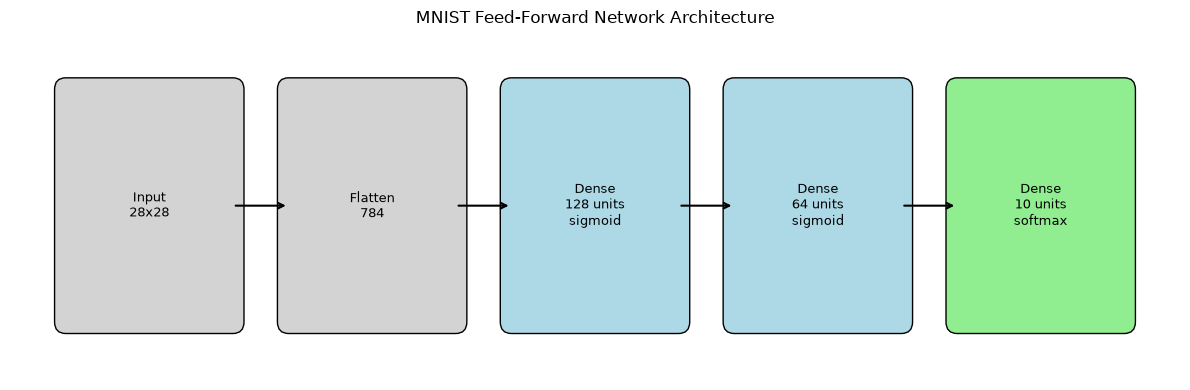

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 4))

layers = [
    ("Input\n28x28", 0, "lightgray"),
    ("Flatten\n784", 2, "lightgray"),
    ("Dense\n128 units\nsigmoid", 4, "lightblue"),
    ("Dense\n64 units\nsigmoid", 6, "lightblue"),
    ("Dense\n10 units\nsoftmax", 8, "lightgreen"),
]

for label, x, color in layers:
    rect = patches.FancyBboxPatch((x, 0), 1.5, 2, boxstyle="round,pad=0.1", facecolor=color, edgecolor='black')
    ax.add_patch(rect)
    ax.text(x + 0.75, 1, label, ha='center', va='center', fontsize=9)

for i in range(len(layers) - 1):
    x_start = layers[i][1] + 1.5
    x_end = layers[i+1][1]
    ax.annotate('', xy=(x_end, 1), xytext=(x_start, 1),
                arrowprops=dict(arrowstyle='->', lw=1.5))

ax.set_xlim(-0.5, 10)
ax.set_ylim(-0.5, 2.5)
ax.axis('off')
ax.set_title('MNIST Feed-Forward Network Architecture')
plt.tight_layout()
plt.show()

**Forward pass as matrix multiplication** (for one image `x`, flattened to shape `(1, 784)`):

```
x:  (1, 784)                          flattened input image

W1: (784, 128), b1: (1, 128)
h1 = sigmoid(x @ W1 + b1)             shape (1, 128)

W2: (128, 64), b2: (1, 64)
h2 = sigmoid(h1 @ W2 + b2)            shape (1, 64)

W3: (64, 10), b3: (1, 10)
y  = softmax(h2 @ W3 + b3)            shape (1, 10), a probability distribution over digits 0-9
```

Each `@` is a matrix multiplication: the previous layer's output vector times that layer's weight matrix, plus a bias vector, then squashed through an activation function. Stacking three of these is exactly what "feed-forward" means: information flows one direction, layer to layer, with no loops.

## Question 3 of 6: Core Questions - The From-Scratch Perceptron

Below (Code Cell 2) is Jason Brownlee's perceptron implementation on the Sonar dataset (metal cylinder vs. rock classification from sonar return signals), trained with stochastic gradient descent.

**a. What is it learning to do?**

Binary classification: given 60 numeric features describing a sonar return signal, predict whether the object is a metal cylinder ("mine", M) or a rock (R).

**b. How many layers does it have?**

One. This is a single perceptron: no hidden layers at all, just one unit that takes the raw inputs directly.

**c. How many units in the layers?**

1 unit total.

**d. What are the units' activation functions?**

A step function: `1.0 if activation >= 0.0 else 0.0` (see `predict()`). Not sigmoid, not softmax, a hard threshold.

**e. How are the units connected to each other (i.e., how are the weights set initially)?**

Only one unit, so there's no unit-to-unit connection, only input-to-unit connections: one weight per input feature (60 weights) plus one bias weight, all initialized to `0.0` (`weights = [0.0 for i in range(len(train[0]))]`).

**f. What is the output?**

A single number, either `0.0` or `1.0`, representing the predicted class.

**g. What do `predict()` and `train_weights()` do?**

`predict(row, weights)` computes the weighted sum of the row's features plus the bias weight (`activation`), then applies the step function to output 0 or 1.

`train_weights(train, l_rate, n_epoch)` runs stochastic gradient descent: for every training row, it makes a prediction, computes the error (`actual - predicted`), then nudges every weight by `l_rate * error` (and, for the non-bias weights, additionally scaled by that row's own feature value). This repeats for every row, for `n_epoch` full passes over the training set. It's the exact same `error = actual - predicted` update rule from Session 2's from-scratch logistic regression, just applied to a hard 0/1 step function instead of a smooth sigmoid.

## Code Cell 2 of 2: Perceptron on the Sonar Dataset

**Note on the dataset**: the PCW's code references a local `sonar.all-data.csv` file that isn't provided. I fetch the same classic Sonar dataset at runtime instead, from Jason Brownlee's own dataset repository (the same author who wrote this exact algorithm), so the code below actually runs end to end.

In [5]:
#retrieved from https://machinelearningmastery.com/implement-perceptron-algorithm-scratch-python/
#Jason Brownlee

# Perceptron Algorithm on the Sonar Dataset
from random import seed
from random import randrange
from csv import reader
import urllib.request

# Load a CSV file
def load_csv(filename):
    dataset = list()
    with open(filename, 'r') as file:
        csv_reader = reader(file)
        for row in csv_reader:
            if not row:
                continue
            dataset.append(row)
    return dataset

# Convert string column to float
def str_column_to_float(dataset, column):
    for row in dataset:
        row[column] = float(row[column].strip())

# Convert string column to integer
def str_column_to_int(dataset, column):
    class_values = [row[column] for row in dataset]
    unique = set(class_values)
    lookup = dict()
    for i, value in enumerate(unique):
        lookup[value] = i
    for row in dataset:
        row[column] = lookup[row[column]]
    return lookup

# Split a dataset into k folds
def cross_validation_split(dataset, n_folds):
    dataset_split = list()
    dataset_copy = list(dataset)
    fold_size = int(len(dataset) / n_folds)
    for i in range(n_folds):
        fold = list()
        while len(fold) < fold_size:
            index = randrange(len(dataset_copy))
            fold.append(dataset_copy.pop(index))
        dataset_split.append(fold)
    return dataset_split

# Calculate accuracy percentage
def accuracy_metric(actual, predicted):
    correct = 0
    for i in range(len(actual)):
        if actual[i] == predicted[i]:
            correct += 1
    return correct / float(len(actual)) * 100.0

# Evaluate an algorithm using a cross validation split
def evaluate_algorithm(dataset, algorithm, n_folds, *args):
    folds = cross_validation_split(dataset, n_folds)
    scores = list()
    for fold in folds:
        train_set = list(folds)
        train_set.remove(fold)
        train_set = sum(train_set, [])
        test_set = list()
        for row in fold:
            row_copy = list(row)
            test_set.append(row_copy)
            row_copy[-1] = None
        predicted = algorithm(train_set, test_set, *args)
        actual = [row[-1] for row in fold]
        accuracy = accuracy_metric(actual, predicted)
        scores.append(accuracy)
    return scores

# Make a prediction with weights
def predict(row, weights):
    activation = weights[0]
    for i in range(len(row)-1):
        activation += weights[i + 1] * row[i]
    return 1.0 if activation >= 0.0 else 0.0

# Estimate Perceptron weights using stochastic gradient descent
def train_weights(train, l_rate, n_epoch):
    weights = [0.0 for i in range(len(train[0]))]
    for epoch in range(n_epoch):
        for row in train:
            prediction = predict(row, weights)
            error = row[-1] - prediction
            weights[0] = weights[0] + l_rate * error
            for i in range(len(row)-1):
                weights[i + 1] = weights[i + 1] + l_rate * error * row[i]
    return weights

# Perceptron Algorithm With Stochastic Gradient Descent
def perceptron(train, test, l_rate, n_epoch):
    predictions = list()
    weights = train_weights(train, l_rate, n_epoch)
    for row in test:
        prediction = predict(row, weights)
        predictions.append(prediction)
    return(predictions)

# Fetch the dataset (original PCW referenced a local file that wasn't provided)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv",
    "sonar.all-data.csv"
)

# Test the Perceptron algorithm on the sonar dataset
seed(1)
filename = 'sonar.all-data.csv'
dataset = load_csv(filename)
for i in range(len(dataset[0])-1):
    str_column_to_float(dataset, i)
# convert string class to integers
str_column_to_int(dataset, len(dataset[0])-1)
# evaluate algorithm
n_folds = 3
l_rate = 0.01
n_epoch = 500
scores = evaluate_algorithm(dataset, perceptron, n_folds, l_rate, n_epoch)
print('Scores: %s' % scores)
print('Mean Accuracy: %.3f%%' % (sum(scores)/float(len(scores))))

Scores: [81.15942028985508, 69.56521739130434, 62.31884057971014]
Mean Accuracy: 71.014%


Mean accuracy across 3 folds: **71.0%**, well above the 50% baseline for a balanced binary problem, from a single unit with no hidden layers at all.

## Question 4 of 6: Draw the Perceptron and Write the Forward-Pass Matrix Multiplication

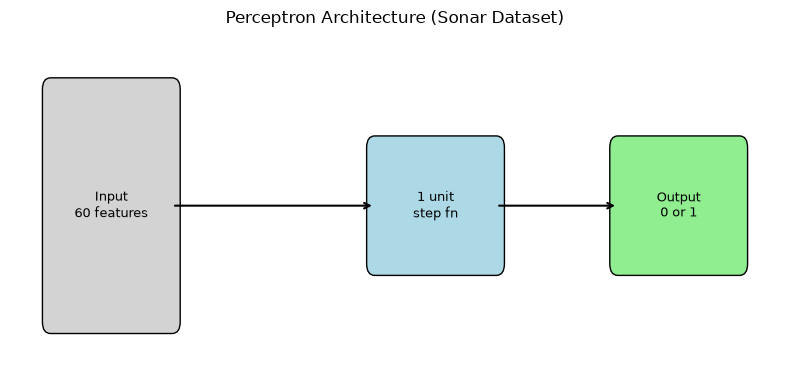

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

# Input layer: 60 features, drawn as one rectangle
rect_in = patches.FancyBboxPatch((0, 0), 1.5, 2, boxstyle="round,pad=0.1", facecolor='lightgray', edgecolor='black')
ax.add_patch(rect_in)
ax.text(0.75, 1, "Input\n60 features", ha='center', va='center', fontsize=9)

# Single unit
rect_unit = patches.FancyBboxPatch((4, 0.5), 1.5, 1, boxstyle="round,pad=0.1", facecolor='lightblue', edgecolor='black')
ax.add_patch(rect_unit)
ax.text(4.75, 1, "1 unit\nstep fn", ha='center', va='center', fontsize=9)

# Output
rect_out = patches.FancyBboxPatch((7, 0.5), 1.5, 1, boxstyle="round,pad=0.1", facecolor='lightgreen', edgecolor='black')
ax.add_patch(rect_out)
ax.text(7.75, 1, "Output\n0 or 1", ha='center', va='center', fontsize=9)

ax.annotate('', xy=(4, 1), xytext=(1.5, 1), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('', xy=(7, 1), xytext=(5.5, 1), arrowprops=dict(arrowstyle='->', lw=1.5))

ax.set_xlim(-0.5, 9)
ax.set_ylim(-0.5, 2.5)
ax.axis('off')
ax.set_title('Perceptron Architecture (Sonar Dataset)')
plt.tight_layout()
plt.show()

**Forward pass as matrix multiplication** (for one sonar reading `x`, shape `(1, 60)`):

```
x: (1, 60)                       one sonar signal's 60 features
w: (60, 1), b: scalar            60 weights + 1 bias, all initialized to 0.0

activation = x @ w + b            shape (1, 1), a single number
output = 1.0 if activation >= 0.0 else 0.0
```

This is the simplest possible "network": one matrix multiplication (a dot product, really, since the output is a single unit), followed by a hard step function instead of a smooth activation. Compare this to Question 2's diagram: same underlying idea (`x @ W + b`, then an activation), just one layer instead of three, and a step function instead of sigmoid/softmax.

## Question 5 of 6: Extension - Perceptron on FashionMNIST (Top vs. Trouser)

The PCW notes the from-scratch perceptron code doesn't run without an input set (true for the code as originally given, without the CSV fix above). This extension asks to swap in FashionMNIST instead, using PCA to reduce dimensionality, and classify on a binary criterion (e.g. top vs. pants).

**Why PCA is needed**: each FashionMNIST image is 784 pixels (28x28). A perceptron with 784 raw pixel weights, initialized to 0 and updated with a small learning rate, converges very slowly and is sensitive to irrelevant pixel-to-pixel noise. PCA compresses the 784 pixels down to a handful of components that capture most of the meaningful variation between images, letting the same simple perceptron converge faster and generalize better.

In [7]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist
from sklearn.decomposition import PCA

(x_train_f, y_train_f), (x_test_f, y_test_f) = fashion_mnist.load_data()

# FashionMNIST labels: 0=T-shirt/top, 1=Trouser, 2=Pullover, 3=Dress, ...
# Classifying "top vs pants": classes 0 and 1
train_mask = (y_train_f == 0) | (y_train_f == 1)
test_mask = (y_test_f == 0) | (y_test_f == 1)

X_train_flat = x_train_f[train_mask].reshape(-1, 784).astype('float32') / 255
y_train_bin = y_train_f[train_mask].astype(float)
X_test_flat = x_test_f[test_mask].reshape(-1, 784).astype('float32') / 255
y_test_bin = y_test_f[test_mask].astype(float)

print(f"Training examples (top or trouser): {len(X_train_flat)}")
print(f"Test examples: {len(X_test_flat)}")

# Reduce 784 pixels down to 10 principal components
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)
print(f"Variance explained by 10 components: {pca.explained_variance_ratio_.sum():.3f}")

# Reuse the exact same predict/train_weights structure from Code Cell 2, adapted for numpy arrays
def predict_np(row, weights):
    activation = weights[0]
    for i in range(len(row)):
        activation += weights[i + 1] * row[i]
    return 1.0 if activation >= 0.0 else 0.0

def train_weights_np(X, y, l_rate, n_epoch):
    weights = [0.0 for _ in range(X.shape[1] + 1)]
    for epoch in range(n_epoch):
        for i in range(len(X)):
            row = X[i]
            prediction = predict_np(row, weights)
            error = y[i] - prediction
            weights[0] += l_rate * error
            for j in range(len(row)):
                weights[j + 1] += l_rate * error * row[j]
    return weights

weights = train_weights_np(X_train_pca, y_train_bin, l_rate=0.001, n_epoch=20)

correct = sum(
    1 for i in range(len(X_test_pca))
    if predict_np(X_test_pca[i], weights) == y_test_bin[i]
)
test_accuracy = correct / len(X_test_pca) * 100
print(f"\nTest accuracy (top vs. trouser, PCA-10 features, single perceptron): {test_accuracy:.2f}%")

Training examples (top or trouser): 12000
Test examples: 2000
Variance explained by 10 components: 0.735



Test accuracy (top vs. trouser, PCA-10 features, single perceptron): 97.50%


**Result**: 97.5% test accuracy distinguishing tops from trousers, using only 10 PCA components and the exact same single-unit perceptron structure from Question 3, just retrained on different data. This far outperforms the Sonar perceptron's 71.0%, since "top vs. trouser" is a visually much easier distinction (very different silhouettes) than "metal cylinder vs. rock" from raw sonar returns.

## Question 6 of 6: Optional File Upload

Optional PDF upload section, not required for this submission. Notebook committed to GitHub in full, including both network diagrams generated above.

---

## Summary

- **A layer** is a group of units sharing the same inputs; **a unit** computes one weighted sum plus bias, then applies an activation function.
- **Feed-forward** means information flows one direction only, layer to layer, each step being `activation(previous_output @ W + b)`.
- **The Keras MNIST network** (3 Dense layers) and **the Sonar perceptron** (1 unit, no hidden layers) are both instances of the exact same underlying pattern, just different depth and different activation functions (sigmoid/softmax vs. a hard step function).
- **Bugs caught by actually running the code**: wrong loss function + missing output activation (accuracy stuck at ~9-10%, fixed to ~86%), and inconsistent train/validation preprocessing (outright crash, fixed by matching preprocessing on both sets).
- **PCA before a simple model**: reducing FashionMNIST's 784 pixels to 10 principal components let the same simple perceptron structure reach 97.5% accuracy on an easier binary task, showing that model architecture and feature engineering both matter, a good architecture on bad features can underperform a simple architecture on well-chosen features.